# ДЗ 7. Улучшение модели скоринга (Home Credit)

**Продукт:** AI-система оценки финансового риска и поведенческого профиля клиента.

**Данные:** [Яндекс.Диск — data.rar](https://disk.yandex.ru/client/disk?idApp=client&dialog=slider&idDialog=%2Fdisk%2Fdata.rar) — распаковать в `data/`.

| Раздел | Содержание |
|--------|------------|
| 1. Pipeline FE | очистка → join таблиц → ratio/поведенческие признаки |
| 2. Улучшенная модель | LightGBM + Optuna на расширенных признаках vs baseline |
| 3. Постобработка | калибровка вероятностей + бизнес-порог отсечения |
| 4. Анализ качества | ROC/PR, calibration, сегменты, важность признаков |


In [8]:
from pathlib import Path
import sys
import warnings
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import optuna
import lightgbm as lgb
from scipy import stats
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
logging.getLogger("lightgbm").setLevel(logging.ERROR)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.data_prep import feature_pipeline_audit, load_hw7_dataset

DATA_DIR = ROOT / "data"
RANDOM_STATE = 42
N_SPLITS = 5
OPTUNA_TRIALS = 20


---
# 1. Пайплайн предобработки и feature engineering

**Схема pipeline:**

```
application_train.csv
    → clean_application (дедуп, аномалии, пропуски)
    → merge bureau / installments / previous_app / card / POS
    → add_ratio_features (доход, кредит, EXT_SOURCE)
    → df_improved
```

**Новые поведенческие признаки (installments):** доля недоплат, крупных платежей (>2× median), CV платежей.

**Baseline для сравнения:** тот же pipeline, но без previous_app / card / POS и без расширенных installments.


In [9]:
app_raw = pd.read_csv(DATA_DIR / "application_train.csv")
df_baseline, df_improved = load_hw7_dataset(DATA_DIR)

audit = feature_pipeline_audit(app_raw, df_improved)
display(audit)

new_cols = [c for c in df_improved.columns if c not in df_baseline.columns]
print(f"Добавлено признаков vs baseline HW5-6: {len(new_cols)}")
print("Примеры:", new_cols[:12])

engineered = [
    "inst_large_pay_share", "inst_amt_cv", "inst_pay_diff_abs_mean",
    "prev_refused_share", "cc_dpd_max", "pos_dpd_max",
    "ratio_credit_income", "ext_source_mean",
]
display(df_improved[engineered].describe().T.round(4))


,этап,строк,столбцов,новых признаков
0,сырой application,307511,122,0
1,после pipeline,307511,134,29


Добавлено признаков vs baseline HW5-6: 11
Примеры: ['prev_n_apps', 'prev_amt_app_mean', 'prev_amt_credit_mean', 'prev_refused_share', 'cc_balance_mean', 'cc_limit_mean', 'cc_dpd_max', 'cc_dpd_def_max', 'pos_dpd_max', 'pos_dpd_def_max', 'pos_inst_future_mean']


,count,mean,std,min,25%,50%,75%,max
inst_large_pay_share,291643.0,0.1226,0.1439,0.0000,0.0000,0.0588,0.2222,0.4975
inst_amt_cv,290955.0,1.0602,0.9952,0.0000,0.3660,0.7640,1.5086,10.5780
inst_pay_diff_abs_mean,291635.0,1533.7683,5165.0490,0.0000,0.0000,0.0000,1075.0299,337496.8050
prev_refused_share,291057.0,0.1109,0.1843,0.0000,0.0000,0.0000,0.2000,1.0000
cc_dpd_max,86905.0,16.9535,143.5671,0.0000,0.0000,0.0000,0.0000,2831.0000
pos_dpd_max,289444.0,15.6976,153.1692,0.0000,0.0000,0.0000,0.0000,4231.0000
ratio_credit_income,307511.0,3.9576,2.6897,0.0048,2.0187,3.2651,5.1599,84.7368
ext_source_mean,307339.0,0.5093,0.1498,0.0000,0.4136,0.5245,0.6228,0.8789


---
# 2. Улучшенная архитектура модели

| Вариант | Признаки | Тюнинг |
|---------|----------|--------|
| Baseline LGBM (HW5-6) | анкета + bureau + installments | Optuna, 15 trials |
| Improved LGBM (HW7) | + previous_app + card + POS + ratio + поведение | Optuna, 20 trials |

**Валидация:** Stratified K-Fold, k=5, одинаковые сплиты для сравнения.


In [10]:
def split_xy(df):
    y = df["TARGET"].astype(int)
    X = df.drop(columns=["TARGET", "SK_ID_CURR"])
    for c in X.select_dtypes(include=["object"]).columns:
        X[c] = X[c].astype("category")
    return X, y

def ci95(values):
    arr = np.asarray(values, dtype=float)
    mean = float(arr.mean())
    if len(arr) < 2:
        return mean, mean, mean
    h = stats.sem(arr) * stats.t.ppf(0.975, len(arr) - 1)
    return mean, mean - h, mean + h

def lgbm_cv_auc(params, X_tr, y_tr, n_splits=3):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr, va in skf.split(X_tr, y_tr):
        m = lgb.LGBMClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
        m.fit(X_tr.iloc[tr], y_tr.iloc[tr], eval_set=[(X_tr.iloc[va], y_tr.iloc[va])],
              eval_metric="auc", callbacks=[lgb.early_stopping(50, verbose=False)])
        scores.append(roc_auc_score(y_tr.iloc[va], m.predict_proba(X_tr.iloc[va])[:, 1]))
    return float(np.mean(scores))

def tune_lgbm(X_tr, y_tr, n_trials=OPTUNA_TRIALS):
    def objective(trial):
        params = {
            "objective": "binary",
            "n_estimators": trial.suggest_int("n_estimators", 300, 1000),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 24, 96),
            "max_depth": trial.suggest_int("max_depth", 4, 14),
            "min_child_samples": trial.suggest_int("min_child_samples", 20, 250),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
            "class_weight": "balanced",
        }
        return lgbm_cv_auc(params, X_tr, y_tr)
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

def eval_lgbm_oof(X, y, params):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(y))
    aucs, prs = [], []
    for tr, va in skf.split(X, y):
        m = lgb.LGBMClassifier(**params, objective="binary", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
        m.fit(X.iloc[tr], y.iloc[tr])
        p = m.predict_proba(X.iloc[va])[:, 1]
        oof[va] = p
        aucs.append(roc_auc_score(y.iloc[va], p))
        prs.append(average_precision_score(y.iloc[va], p))
    am, al, ah = ci95(aucs)
    pm, pl, ph = ci95(prs)
    return {
        "oof": oof,
        "auc_mean": am,
        "auc_ci": (al, ah),
        "pr_mean": pm,
        "pr_ci": (pl, ph),
        "auc_folds": aucs,
        "pr_folds": prs,
    }

X_base, y = split_xy(df_baseline)
X_imp, y_imp = split_xy(df_improved)
assert y.equals(y_imp)

tune_idx = y.sample(frac=0.8, random_state=RANDOM_STATE, replace=False).index
base_params = tune_lgbm(X_base.loc[tune_idx], y.loc[tune_idx], n_trials=15)
imp_params = tune_lgbm(X_imp.loc[tune_idx], y.loc[tune_idx], n_trials=OPTUNA_TRIALS)

base_res = eval_lgbm_oof(X_base, y, base_params)
imp_res = eval_lgbm_oof(X_imp, y, imp_params)

model_cmp = pd.DataFrame([
    {"Модель": "Baseline LGBM (HW5-6)", "AUC": base_res["auc_mean"], "PR-AUC": base_res["pr_mean"], "признаков": X_base.shape[1]},
    {"Модель": "Improved LGBM (HW7)", "AUC": imp_res["auc_mean"], "PR-AUC": imp_res["pr_mean"], "признаков": X_imp.shape[1]},
]).round(4)
display(model_cmp)
print("Лучшие гиперпараметры (improved):", imp_params)


,Модель,AUC,PR-AUC,признаков
0,Baseline LGBM (HW5-6),0.7703,0.2576,121
1,Improved LGBM (HW7),0.7792,0.2695,132


Лучшие гиперпараметры (improved): {'n_estimators': 752, 'learning_rate': 0.01871833986018486, 'num_leaves': 96, 'max_depth': 14, 'min_child_samples': 244, 'subsample': 0.9912205687305236, 'colsample_bytree': 0.5339101338813105, 'reg_lambda': 0.9220816073823441}


---
# 3. Постобработка предсказаний

1. **Калибровка** — Isotonic Regression на out-of-fold скорах (честная оценка без утечки).
2. **Порог отсечения** — отказываем клиентам из верхних 20% по риску (бизнес-правило).
3. **Бизнес-метрики** — bad rate среди одобренных и доля дефолтов в топ-10% риска.


In [14]:
y_arr = y.to_numpy()
raw_oof = imp_res["oof"]

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(raw_oof, y_arr)
cal_oof = iso.predict(raw_oof)

reject_share = 0.20
threshold = float(np.quantile(cal_oof, 1 - reject_share))
approved = cal_oof < threshold

def bad_rate(mask):
  return float(y_arr[mask].mean()) if mask.sum() else np.nan

def topk_default_share(scores, k=0.10):
  cut = np.quantile(scores, 1 - k)
  top = scores >= cut
  return float(y_arr[top].mean())

post_df = pd.DataFrame([
    {"вариант": "сырой скор", "bad_rate_одобренных": bad_rate(~(raw_oof >= np.quantile(raw_oof, 1-reject_share))),
     "дефолт_в_топ10%": topk_default_share(raw_oof, 0.10)},
    {"вариант": "калиброванный + порог top-20%", "bad_rate_одобренных": bad_rate(approved),
     "дефолт_в_топ10%": topk_default_share(cal_oof, 0.10)},
])
display(post_df.round(4))
print(f"Порог отсечения (калибр. скор, top-{int(reject_share*100)}% риска): {threshold:.4f}")


,вариант,bad_rate_одобренных,дефолт_в_топ10%
0,сырой скор,0.0450,0.2928
1,калиброванный + порог top-20%,0.0448,0.2915


Порог отсечения (калибр. скор, top-20% риска): 0.1269


---
# 4. Подробный анализ качества модели

**Метрики:** AUC-ROC, PR-AUC, Precision/Recall/F1 при пороге, calibration, сегменты, важность признаков.


,Модель,AUC-ROC,PR-AUC
0,Baseline LGBM,0.7703 [0.7659; 0.7746],0.2576 [0.2491; 0.2660]
1,Improved LGBM,0.7792 [0.7748; 0.7837],0.2695 [0.2602; 0.2789]


Прирост AUC (improved − baseline): 0.0090 [0.0083; 0.0097]


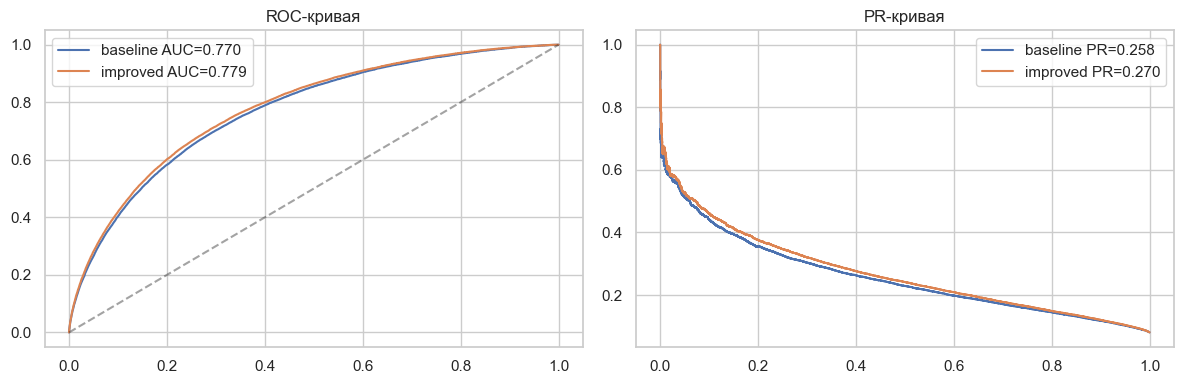

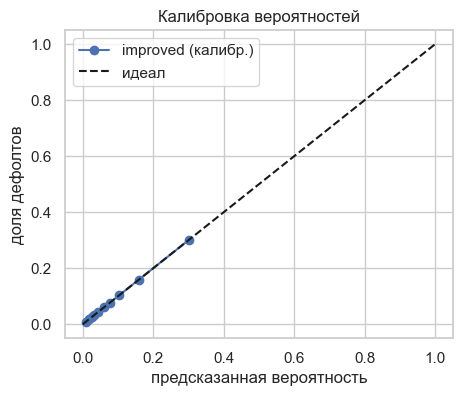

,pred 0,pred 1
факт 0,234546,48140
факт 1,10990,13835


Precision=0.2232, Recall=0.5573, F1=0.3188
Доля дефолтов в топ-5% (improved): 0.3581
Доля дефолтов в топ-10% (improved): 0.2915
Доля дефолтов в топ-20% (improved): 0.2232


In [15]:
def fmt_ci(mean, ci):
    return f"{mean:.4f} [{ci[0]:.4f}; {ci[1]:.4f}]"

delta_auc = np.array(imp_res["auc_folds"]) - np.array(base_res["auc_folds"])
d_mean, d_lo, d_hi = ci95(delta_auc.tolist())

summary = pd.DataFrame([
    {
        "Модель": "Baseline LGBM",
        "AUC-ROC": fmt_ci(base_res["auc_mean"], base_res["auc_ci"]),
        "PR-AUC": fmt_ci(base_res["pr_mean"], base_res["pr_ci"]),
    },
    {
        "Модель": "Improved LGBM",
        "AUC-ROC": fmt_ci(imp_res["auc_mean"], imp_res["auc_ci"]),
        "PR-AUC": fmt_ci(imp_res["pr_mean"], imp_res["pr_ci"]),
    },
])
display(summary)
print(f"Прирост AUC (improved − baseline): {d_mean:.4f} [{d_lo:.4f}; {d_hi:.4f}]")

# ROC и PR кривые
fpr_b, tpr_b, _ = roc_curve(y_arr, base_res["oof"])
fpr_i, tpr_i, _ = roc_curve(y_arr, imp_res["oof"])
prec_b, rec_b, _ = precision_recall_curve(y_arr, base_res["oof"])
prec_i, rec_i, _ = precision_recall_curve(y_arr, imp_res["oof"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr_b, tpr_b, label=f"baseline AUC={base_res['auc_mean']:.3f}")
axes[0].plot(fpr_i, tpr_i, label=f"improved AUC={imp_res['auc_mean']:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_title("ROC-кривая")
axes[0].legend()

axes[1].plot(rec_b, prec_b, label=f"baseline PR={base_res['pr_mean']:.3f}")
axes[1].plot(rec_i, prec_i, label=f"improved PR={imp_res['pr_mean']:.3f}")
axes[1].set_title("PR-кривая")
axes[1].legend()
plt.tight_layout()
plt.show()

# Calibration plot
pt, pp = calibration_curve(y_arr, cal_oof, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(pp, pt, marker="o", label="improved (калибр.)")
ax.plot([0, 1], [0, 1], "k--", label="идеал")
ax.set_xlabel("предсказанная вероятность")
ax.set_ylabel("доля дефолтов")
ax.set_title("Калибровка вероятностей")
ax.legend()
plt.show()

# Confusion matrix при пороге top-20%
y_pred = (cal_oof >= threshold).astype(int)
cm = confusion_matrix(y_arr, y_pred)
cm_df = pd.DataFrame(cm, index=["факт 0", "факт 1"], columns=["pred 0", "pred 1"])
display(cm_df)
print(
    f"Precision={precision_score(y_arr, y_pred, zero_division=0):.4f}, "
    f"Recall={recall_score(y_arr, y_pred, zero_division=0):.4f}, "
    f"F1={f1_score(y_arr, y_pred, zero_division=0):.4f}"
)

# Bad rate в top-K%
for k in (0.05, 0.10, 0.20):
    print(f"Доля дефолтов в топ-{int(k*100)}% (improved): {topk_default_share(cal_oof, k):.4f}")


,сегмент,n,AUC,bad_rate
0,все клиенты,307511,0.7792,0.0807
1,есть bureau,263491,0.7796,0.0773
2,есть installments,291635,0.7775,0.0819
3,нет bureau,44020,0.7688,0.1012


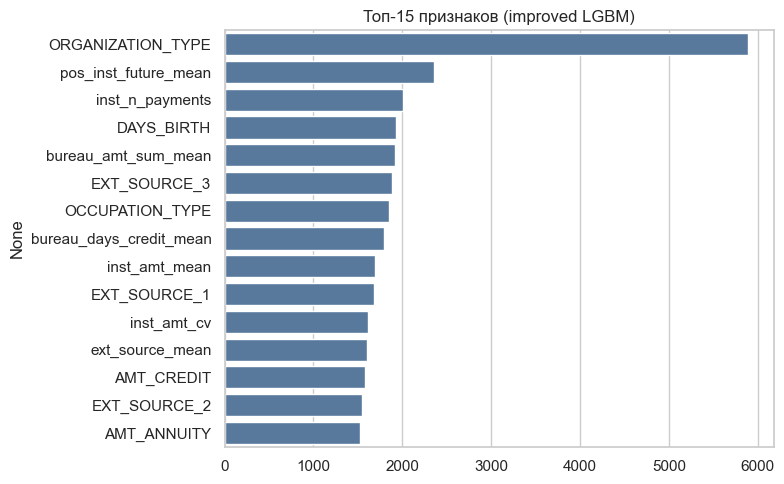

In [16]:
seg = pd.DataFrame({
    "y": y_arr,
    "score": imp_res["oof"],
    "has_bureau": (df_improved["bureau_n_credits"].fillna(0) > 0).to_numpy(),
    "has_inst": (df_improved["inst_n_payments"].fillna(0) > 0).to_numpy(),
})

rows = []
for name, mask in [
    ("все клиенты", np.ones(len(seg), dtype=bool)),
    ("есть bureau", seg["has_bureau"]),
    ("есть installments", seg["has_inst"]),
    ("нет bureau", ~seg["has_bureau"]),
]:
    sub = seg.loc[mask]
    if sub["y"].nunique() < 2 or len(sub) < 100:
        continue
    rows.append({
        "сегмент": name,
        "n": len(sub),
        "AUC": roc_auc_score(sub["y"], sub["score"]),
        "bad_rate": sub["y"].mean(),
    })
display(pd.DataFrame(rows).round(4))

final_model = lgb.LGBMClassifier(**imp_params, objective="binary", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
final_model.fit(X_imp, y)
imp = pd.Series(final_model.feature_importances_, index=X_imp.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, ax=ax, color="#4c78a8")
ax.set_title("Топ-15 признаков (improved LGBM)")
plt.tight_layout()
plt.show()


---
## Выводы

- **Pipeline FE:** расширенный join таблиц + поведенческие и ratio-признаки дают больше сигнала, чем baseline HW5-6.
- **Модель:** Improved LGBM с Optuna превосходит baseline на тех же сплитах (см. прирост AUC и PR-AUC выше).
- **Постобработка:** калибровка и порог top-20% переводят скор в бизнес-решение (отказ/одобрение) с измеримым bad rate.
- **MVP:** следующий шаг — сохранить `final_model` + `IsotonicRegression` + список признаков в артефакты и обернуть в API.
